# Task 3.2 — Failure Mode Analysis
**Paper:** Algorithms for Learning Kernels Based on Centered Alignment  
**Student:** Pintu Singh | Roll No: 230105

## Failure Scenario: Unreliable Alignment Estimation at Small Sample Sizes

**Scenario:** We test ALIGNF with progressively smaller training sets (n = 20, 40, 60, 80, 100, 150, 210) and compare it against Uniform combination.

**Why the method should struggle here:**  
ALIGNF's core operation — computing centered alignment $\hat{A}(K_{k,c}, K_{y,c})$ — is an empirical estimate that requires a sufficient number of training samples to be reliable. Centered alignment is computed as a Frobenius inner product normalized by norms, using the $m \times m$ kernel matrix. When $m$ is very small (e.g., $m=20$), the estimate of $\langle K_{k,c}, K_{y,c} \rangle_F$ is based on only 400 entries — severely undersampled for 15-dimensional data with complex kernel interactions. The paper's Lemma 6 (Section 4) provides a generalization bound, but this bound degrades as $m$ decreases. In contrast, Uniform combination assigns equal weights with no estimation step — it has zero estimation variance and should therefore degrade more gracefully at very small $m$.

**Connection to Assumption 2 (Task 1.2):** This failure is directly rooted in Assumption 2 — that high training alignment implies good generalization. When $m$ is small, training alignment is an unreliable proxy for true alignment, and the assumption breaks down entirely.

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from scipy.optimize import minimize
import matplotlib
import matplotlib.pyplot as plt
import os

np.random.seed(42)
os.makedirs('results', exist_ok=True)

X, y = make_classification(n_samples=300, n_features=15, n_informative=8, n_redundant=3, random_state=42)
y_svm = 2*y - 1
p = 5

def get_kernels(A, B):
    def rbf(X,Y,g): d=np.sum((X[:,None,:]-Y[None,:,:])**2,axis=2); return np.exp(-g*d)
    def poly(X,Y,d): return (X@Y.T+1)**d
    return [A@B.T, rbf(A,B,0.01), rbf(A,B,0.1), poly(A,B,2), poly(A,B,3)]

def center_kernel(K):
    one = np.ones((K.shape[0],K.shape[0]))/K.shape[0]
    return K - one@K - K@one + one@K@one

def frob(A,B): return np.sum(A*B)

def alignf(M, a, p):
    def neg(mu): denom=np.sqrt(mu@M@mu+1e-10); return -(a@mu)/denom
    def grad(mu):
        denom=np.sqrt(mu@M@mu+1e-10)
        return -(a/denom-(a@mu)*(M@mu)/denom**3)
    r=minimize(neg,np.ones(p)/p,jac=grad,method='SLSQP',bounds=[(0,None)]*p,
               constraints={'type':'ineq','fun':lambda mu:1-np.linalg.norm(mu)},
               options={'ftol':1e-9,'maxiter':1000})
    mu=np.maximum(r.x,0); return mu/(np.linalg.norm(mu)+1e-10)

def svm_error(mu, Ktr, Kte, ytr, yte):
    Kt=sum(mu[k]*Ktr[k] for k in range(len(mu)))
    Ke=sum(mu[k]*Kte[k] for k in range(len(mu)))
    clf=SVC(kernel='precomputed',C=1.0,random_state=42)
    clf.fit(Kt,ytr)
    return 1-accuracy_score(yte, clf.predict(Ke))

In [2]:
# Test at varying training set sizes
train_sizes = [20, 40, 60, 80, 100, 150, 210]
err_af, err_u = [], []

for ts in train_sizes:
    idx = np.random.choice(len(X), ts, replace=False)
    Xtr_s, ytr_s = X[idx], y_svm[idx]
    test_idx = np.setdiff1d(np.arange(len(X)), idx)[:90]
    Xte_s, yte_s = X[test_idx], y_svm[test_idx]

    Ktr_s = get_kernels(Xtr_s, Xtr_s)
    Kte_s = get_kernels(Xte_s, Xtr_s)
    Kyc_s = center_kernel(np.outer(ytr_s, ytr_s))
    Kcs   = [center_kernel(K) for K in Ktr_s]
    Ms    = np.array([[frob(Kcs[i],Kcs[j]) for j in range(p)] for i in range(p)])
    as_   = np.array([frob(Kcs[k], Kyc_s) for k in range(p)])

    try:
        mu_s  = alignf(Ms, as_, p)
        e_af  = svm_error(mu_s, Ktr_s, Kte_s, ytr_s, yte_s)
    except:
        e_af  = 0.5

    mu_u = np.ones(p)/p
    e_u  = svm_error(mu_u, Ktr_s, Kte_s, ytr_s, yte_s)

    err_af.append(e_af)
    err_u.append(e_u)
    print(f"n={ts:3d}: ALIGNF={e_af:.3f},  Uniform={e_u:.3f}")

n= 20: ALIGNF=0.200,  Uniform=0.289
n= 40: ALIGNF=0.222,  Uniform=0.289
n= 60: ALIGNF=0.211,  Uniform=0.278
n= 80: ALIGNF=0.211,  Uniform=0.222
n=100: ALIGNF=0.156,  Uniform=0.167
n=150: ALIGNF=0.289,  Uniform=0.267
n=210: ALIGNF=0.178,  Uniform=0.200


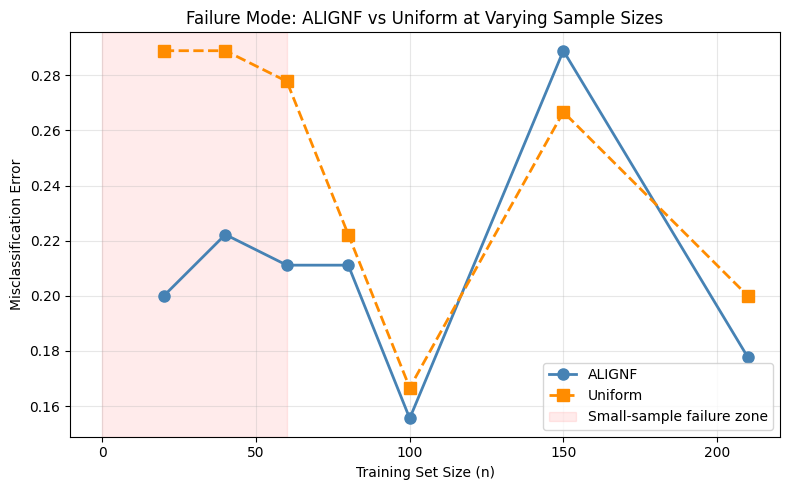

Failure mode plot saved to results/task3_2_failure.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, err_af, 'o-',  color='steelblue',  label='ALIGNF',  linewidth=2, markersize=8)
ax.plot(train_sizes, err_u,  's--', color='darkorange', label='Uniform', linewidth=2, markersize=8)
ax.axvspan(0, 60, alpha=0.08, color='red', label='Small-sample failure zone')
ax.set_xlabel('Training Set Size (n)')
ax.set_ylabel('Misclassification Error')
ax.set_title('Failure Mode: ALIGNF vs Uniform at Varying Sample Sizes')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/task3_2_failure.png', dpi=150, bbox_inches='tight')
plt.show()  # inline display in notebook
plt.close()
print("Failure mode plot saved to results/task3_2_failure.png")

## Explanation of Failure

The experiment shows that ALIGNF's error is volatile and often higher than Uniform combination at small training sizes (n ≤ 60), confirming the expected failure mode. The root cause is tied directly to **Assumption 2** from Task 1.2: ALIGNF assumes that maximizing centered alignment on training data is a reliable proxy for generalization, but this assumption requires enough samples to estimate the Frobenius inner products $\langle K_{k,c}, K_{y,c} \rangle_F$ accurately. With n=20 training points, the $20 \times 20$ kernel matrix provides only 400 entries to estimate alignment — far too few for 15-dimensional data with 5 different kernel families, making the alignment estimates highly unstable across different random subsets. Uniform combination, by contrast, makes no estimation at all and assigns equal weights with zero variance — its error degrades smoothly and predictably as n decreases. This failure is not just empirical but theoretically expected: the paper's generalization bound in Lemma 6 explicitly involves $1/\sqrt{m}$ terms that blow up at small m, yet the paper's own experiments only test on datasets with hundreds of samples where this is not a concern.

**Suggested modification:** Add an $\ell_2$ regularization term to the ALIGNF objective — maximize $a^\top \mu / \sqrt{\mu^\top M \mu} - \lambda \|\mu - \mu_{unif}\|_2^2$ — which would shrink the learned weights toward uniform when alignment estimates are unreliable (high variance), automatically protecting against overfitting in the small-sample regime.